# L03 · ggplot geoms, stats, positions and coordinates (seaborn version)

*Companion notebook to **Section 1.3 (Lecture 3)** of the LaTeX notes (`latex/main.pdf`). Run the cells top to bottom.*

In [1]:
# --- Setup: imports, fixed seed, and a relative path to the data/ folder ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

rng = np.random.default_rng(2024)          # fixed seed for reproducibility
np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.precision", 4)
sns.set_theme(style="whitegrid")

# Find the project's data/ folder by walking up from the notebook's folder.
DATA = next(p / "data" for p in [Path.cwd(), *Path.cwd().parents] if (p / "data").is_dir())
print("data folder:", DATA)

data folder: /home/claude/LSM/data


## Theory recap
A **geom** is the object that represents the data (point, smooth, bar). A **stat** is the transformation applied first. `geom_bar` = `stat_count` + bars, where the count for level $c$ is $n_c=\#\{i:x_i=c\}$. Layered grammar:
`ggplot(data) + GEOM(mapping, stat, position) + COORDINATES + FACETS`.

In [2]:
from statsmodels.nonparametric.smoothers_lowess import lowess
mpg = pd.read_csv(DATA / "mpg.csv")

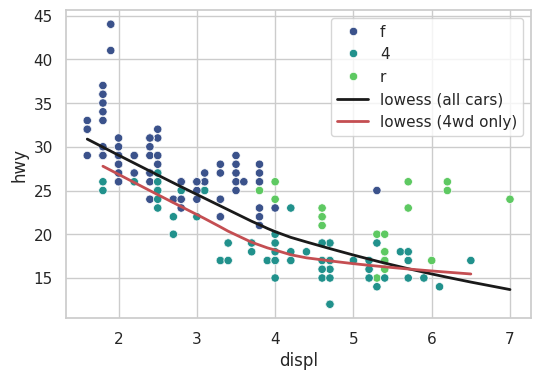

smooth at displ=2: 29.0
smooth at displ=5: 17.6
smooth at displ=6: 15.5


In [3]:
# geom_point + geom_smooth (LOESS). statsmodels' lowess uses local *linear* fits.
sm = lowess(mpg.hwy, mpg.displ, frac=0.75)
fig, ax = plt.subplots(figsize=(6, 4))
sns.scatterplot(data=mpg, x="displ", y="hwy", hue="drv", palette="viridis", ax=ax)   # local mapping colour = drv
ax.plot(sm[:, 0], sm[:, 1], color="k", lw=2, label="lowess (all cars)")
four = mpg[mpg.drv == "4"]                                                             # filter(mpg, drv == "4")
sm4 = lowess(four.hwy, four.displ, frac=0.75)
ax.plot(sm4[:, 0], sm4[:, 1], color="C3", lw=2, label="lowess (4wd only)")
ax.legend(); plt.show()
for x0 in [2, 5, 6]:
    print(f"smooth at displ={x0}: {np.interp(x0, sm[:, 0], sm[:, 1]):.1f}")

class
2seater        5
compact       47
midsize       41
minivan       11
pickup        33
subcompact    35
suv           62
Name: count, dtype: int64 
total = 234


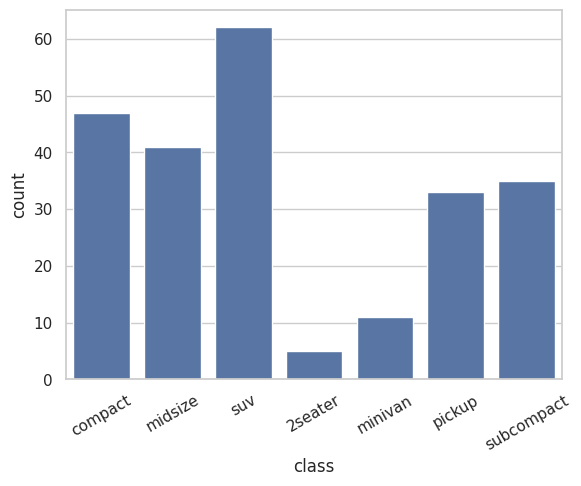

In [4]:
# geom_bar / stat_count  ==  table(mpg$class)
counts = mpg["class"].value_counts().sort_index()
print(counts, "\ntotal =", counts.sum())
sns.countplot(data=mpg, x="class", color="C0"); plt.xticks(rotation=30); plt.show()

            min  median  max
class                       
2seater      23    25.0   26
compact      23    27.0   44
midsize      23    27.0   32
minivan      17    23.0   24
pickup       12    17.0   22
subcompact   20    26.0   44
suv          12    17.5   27


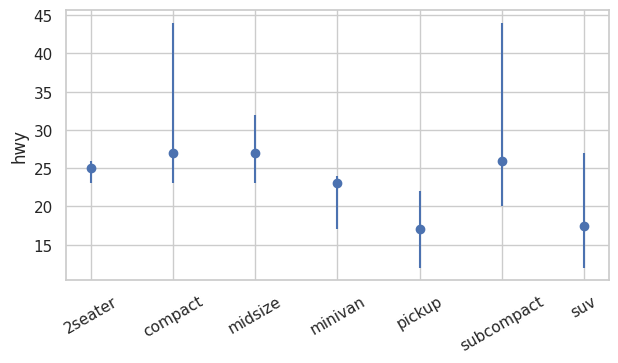

In [5]:
# stat_summary(fun.min = min, fun.max = max, fun = median)
summ = mpg.groupby("class").hwy.agg(["min", "median", "max"])
print(summ)
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.vlines(summ.index, summ["min"], summ["max"]); ax.plot(summ.index, summ["median"], "o")
ax.set_ylabel("hwy"); plt.xticks(rotation=30); plt.show()

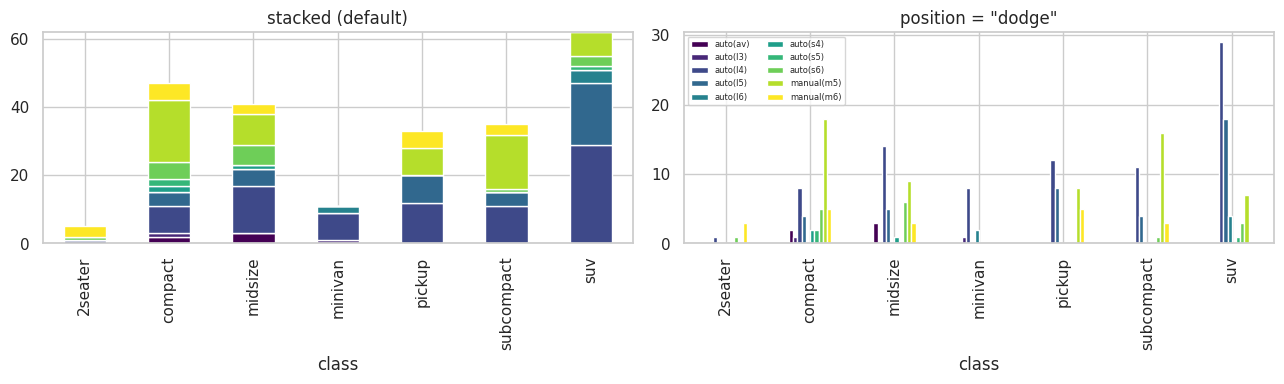

In [6]:
# fill = trans stacked vs position = "dodge"
ct = pd.crosstab(mpg["class"], mpg.trans)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ct.plot.bar(stacked=True, ax=ax[0], colormap="viridis", legend=False, title="stacked (default)")
ct.plot.bar(stacked=False, ax=ax[1], colormap="viridis", title='position = "dodge"')
ax[1].legend(fontsize=6, ncol=2); plt.tight_layout(); plt.show()

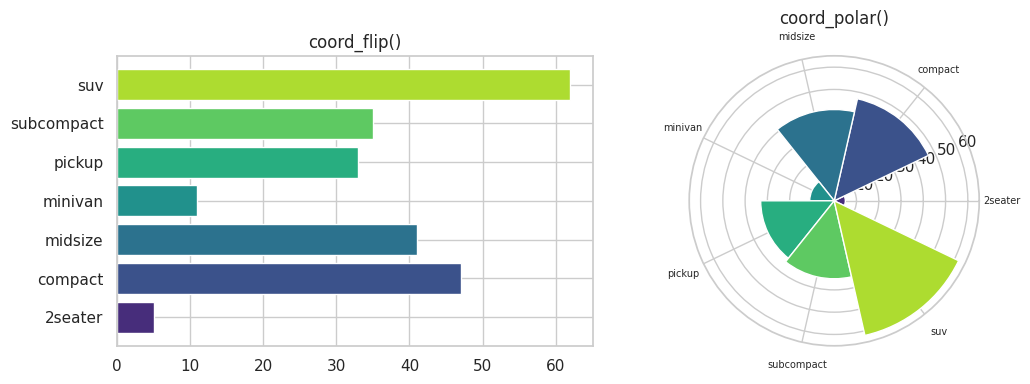

In [7]:
# coord_flip() and coord_polar()
fig = plt.figure(figsize=(11, 4))
ax1 = fig.add_subplot(1, 2, 1); ax1.barh(counts.index, counts.values, color=sns.color_palette("viridis", 7)); ax1.set_title("coord_flip()")
ax2 = fig.add_subplot(1, 2, 2, projection="polar")
theta = np.linspace(0, 2 * np.pi, len(counts), endpoint=False)
ax2.bar(theta, counts.values, width=2 * np.pi / len(counts), color=sns.color_palette("viridis", 7))
ax2.set_xticks(theta); ax2.set_xticklabels(counts.index, fontsize=7); ax2.set_title("coord_polar()")
plt.tight_layout(); plt.show()

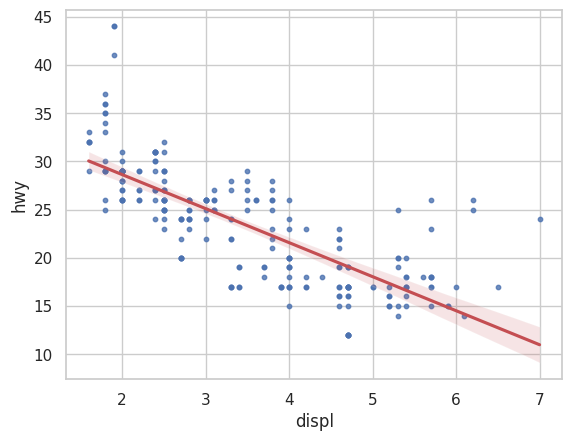

In [8]:
# geom_smooth(method = "lm"): the global least-squares line (preview of Week 2)
sns.regplot(data=mpg, x="displ", y="hwy", scatter_kws=dict(s=10), line_kws=dict(color="C3"))
plt.show()

## Try it yourself
1. Repeat the `stat_summary` table for `cty`. Which class has the largest range? (Exercise 2.)
2. `pd.crosstab(mpg["class"], mpg.drv)` — which class has all three drive types? (Exercise 4.)
3. Change `frac` in `lowess` to 0.2 and 0.9. What happens to the curve?